In [1]:
import os
from torchvision import io as tvio
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils

In [3]:
from typing import Callable, Dict, List, Tuple


class KhayyamCharsDataset(Dataset):
    def __init__(self, root_dir: str, char_range: Tuple[int,int], char_type: int = 1, transform: Callable =None):
        self.root_dir = root_dir
        self.idx_min = char_range[0]
        self.idx_max = char_range[1]
        self.char_type = char_type
        self.transform = transform

        self.data : List[Tuple[str,int]] = []
        self.count_per_class: Dict[int,int] = {}
        
        # char_idx shows charater index. for exmaple 2 for b
        # char type shows which verison. 1 shows isolated character.
        for char_idx in range(self.idx_min,self.idx_max):
            class_idx = char_idx - self.idx_min
            dir_path = f"{self.root_dir}/{char_idx}/{self.char_type}"
            filenames = os.listdir(dir_path)
            self.count_per_class[class_idx] = len(filenames)
            for file_name in filenames:
                    assert file_name[-4:] == ".jpg"
                    self.data.append((f"{dir_path}/{file_name}", class_idx))
        
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image_path,class_idx = self.data[idx]
        image = tvio.read_image(image_path)
        if self.transform is not None:
            image = self.transform(image)
        return (image, class_idx)

In [4]:
dataset = KhayyamCharsDataset(
    root_dir="/mnt/speech6/bagher/nafshar/datasets/khayyam/1st",
    char_range=(10,13),
    char_type=1,
    transform=transforms.Compose([
        transforms.ToPILImage(),
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((28,28)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5,),std=(0.5,))
    ]),
)

In [5]:
dataset.count_per_class

{0: 524, 1: 588, 2: 599}

In [6]:
len(dataset)

1711

In [7]:
image,class_idx = dataset[3]

In [8]:
import matplotlib.pyplot as plt
from torchvision.transforms import ToPILImage
import torch

In [9]:
ToPILImage()(image)

In [10]:

train_loader = torch.utils.data.DataLoader(
    dataset, batch_size=20, shuffle=True, drop_last=True
)

In [11]:
from torchvision.utils import make_grid


torch.Size([20, 1, 28, 28])
torch.Size([20])
tensor([0, 1, 1, 1, 2, 0, 2, 2, 1, 2, 0, 2, 1, 2, 2, 0, 0, 1, 0, 1])


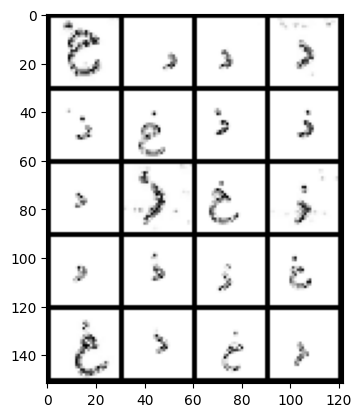

In [12]:
for batch in train_loader:
    print(batch[0].shape)
    print(batch[1].shape)
    print(batch[1])
    grid = make_grid(batch[0],nrow=4)
    img = ToPILImage()(grid)
    plt.imshow(img)
    break

In [13]:

from torchcfm.conditional_flow_matching import *
from torchcfm.models.unet import UNetModel
from torchdyn.core import NeuralODE
from tqdm import tqdm


savedir = "models/khayyam_char"
os.makedirs(savedir, exist_ok=True)

In [14]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
batch_size = 16
n_epochs = 5

trainset = dataset

train_loader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, drop_last=True
)

## Optimal Transport (Non Conditional)

In [15]:
#################################
#            OT-CFM
#################################

sigma = 0.0
model = UNetModel(dim=(1, 28, 28), num_channels=32, num_res_blocks=1).to(device)
optimizer = torch.optim.Adam(model.parameters())
# FM = ConditionalFlowMatcher(sigma=sigma)
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma)
node = NeuralODE(model, solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4)

In [16]:
for epoch in range(n_epochs):
    for i, data in tqdm(enumerate(train_loader)):
        optimizer.zero_grad()
        x1 = data[0].to(device)
        x0 = torch.randn_like(x1)
        t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)
        vt = model(t, xt)
        loss = torch.mean((vt - ut) ** 2)
        loss.backward()
        optimizer.step()

106it [00:10, 10.25it/s]
106it [00:04, 22.32it/s]
106it [00:04, 22.69it/s]
106it [00:04, 21.63it/s]
106it [00:04, 21.69it/s]


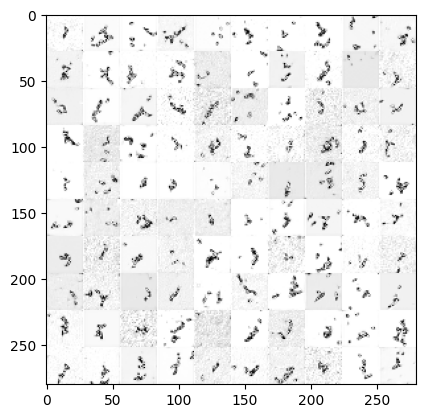

In [17]:
with torch.no_grad():
    traj = node.trajectory(
        torch.randn(100, 1, 28, 28, device=device),
        t_span=torch.linspace(0, 1, 2, device=device),
    )
grid = make_grid(
    traj[-1, :100].view([-1, 1, 28, 28]).clip(-1, 1), value_range=(-1, 1), padding=0, nrow=10
)
img = ToPILImage()(grid)
plt.imshow(img)

In [18]:
#################################
#            SF2M
#################################
batch_size = 128
n_epochs = 10
sigma = 0.1

# We note that with a little bit of effort these two networks can be combined to a single network with two prediction heads
# We leave it this way for simplicity in the notebook, but encourage you to consider supplying the `learn_sigma=True` parameter
# to the UNetModel, which outputs a shape (batch, 2, 28, 28), and can be used to increase efficiency.
model = UNetModel(dim=(1, 28, 28), num_channels=32, num_res_blocks=1).to(device)
score_model = UNetModel(dim=(1, 28, 28), num_channels=32, num_res_blocks=1).to(device)

optimizer = torch.optim.Adam(list(model.parameters()) + list(score_model.parameters()))
FM = SchrodingerBridgeConditionalFlowMatcher(sigma=sigma)
node = NeuralODE(model, solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4)

In [19]:
for epoch in range(n_epochs):
    for i, data in tqdm(enumerate(train_loader)):
        optimizer.zero_grad()
        x1 = data[0].to(device)
        x0 = torch.randn_like(x1)
        t, xt, ut, eps = FM.sample_location_and_conditional_flow(x0, x1, return_noise=True)
        lambda_t = FM.compute_lambda(t)
        vt = model(t, xt)
        st = score_model(t, xt)
        flow_loss = torch.mean((vt - ut) ** 2)
        score_loss = torch.mean((lambda_t[:, None, None, None] * st + eps) ** 2)
        loss = flow_loss + score_loss
        loss.backward()
        optimizer.step()

106it [00:08, 12.44it/s]
106it [00:08, 12.62it/s]
106it [00:08, 12.42it/s]
106it [00:08, 12.89it/s]
106it [00:08, 12.55it/s]
106it [00:08, 12.77it/s]
106it [00:08, 12.68it/s]
106it [00:08, 12.60it/s]
106it [00:08, 12.61it/s]
106it [00:08, 12.60it/s]


/mnt/speech6/bagher/nafshar/projects/conditional-flow-matching/venv/lib/python3.10/site-packages/torchdyn/numerics/odeint.py:83: UserWarning: Setting tolerances has no effect on fixed-step methods
  warn("Setting tolerances has no effect on fixed-step methods")


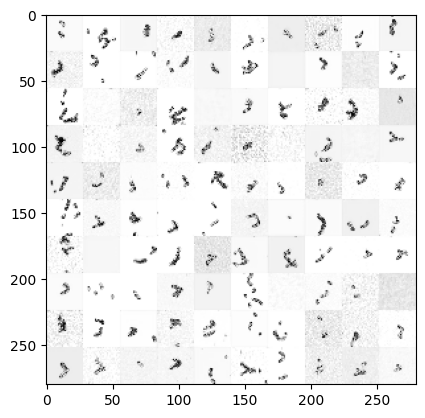

In [20]:
node = NeuralODE(model, solver="euler", sensitivity="adjoint", atol=1e-4, rtol=1e-4)
# Evaluate the ODE
with torch.no_grad():
    traj = node.trajectory(
        torch.randn(100, 1, 28, 28, device=device),
        t_span=torch.linspace(0, 1, 1000, device=device),
    )
grid = make_grid(
    traj[-1, :100].view([-1, 1, 28, 28]).clip(-1, 1), value_range=(-1, 1), padding=0, nrow=10
)
img = ToPILImage()(grid)
plt.imshow(img)

## Conditional Flow Matching

In [27]:
import torchdiffeq


In [22]:
#################################
#    Class Conditional CFM
#################################

sigma = 0.0
model = UNetModel(
    dim=(1, 28, 28), num_channels=32, num_res_blocks=1, num_classes=10, class_cond=True
).to(device)
optimizer = torch.optim.Adam(model.parameters())
FM = ConditionalFlowMatcher(sigma=sigma)
# Users can try target FM by changing the above line by
# FM = TargetConditionalFlowMatcher(sigma=sigma)
node = NeuralODE(model, solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4)

In [23]:
for epoch in range(n_epochs):
    for i, data in enumerate(train_loader):
        optimizer.zero_grad()
        x1 = data[0].to(device)
        y = data[1].to(device)
        x0 = torch.randn_like(x1)
        t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)
        vt = model(t, xt, y)
        loss = torch.mean((vt - ut) ** 2)
        loss.backward()
        optimizer.step()
        print(f"epoch: {epoch}, steps: {i}, loss: {loss.item():.4}", end="\r")

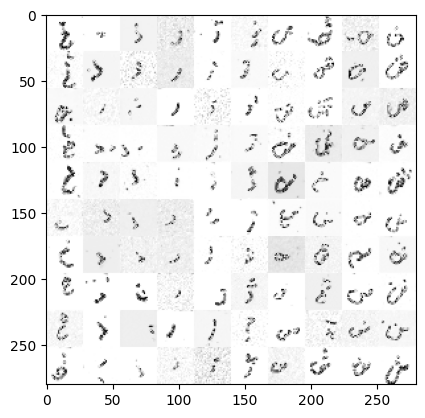

In [24]:
USE_TORCH_DIFFEQ = True
generated_class_list = torch.arange(10, device=device).repeat(10)
with torch.no_grad():
    if USE_TORCH_DIFFEQ:
        traj = torchdiffeq.odeint(
            lambda t, x: model.forward(t, x, generated_class_list),
            torch.randn(100, 1, 28, 28, device=device),
            torch.linspace(0, 1, 2, device=device),
            atol=1e-4,
            rtol=1e-4,
            method="dopri5",
        )
    else:
        traj = node.trajectory(
            torch.randn(100, 1, 28, 28, device=device),
            t_span=torch.linspace(0, 1, 2, device=device),
        )
grid = make_grid(
    traj[-1, :100].view([-1, 1, 28, 28]).clip(-1, 1), value_range=(-1, 1), padding=0, nrow=10
)
img = ToPILImage()(grid)
plt.imshow(img)
plt.show()

### with 64*64 images

In [21]:

from torchcfm.conditional_flow_matching import *
from torchcfm.models.unet import UNetModel
from torchdyn.core import NeuralODE
from tqdm import tqdm

In [22]:
dataset_64 = KhayyamCharsDataset(
    root_dir="/mnt/speech6/bagher/nafshar/datasets/khayyam/1st",
    char_range=(10,20),
    char_type=1,
    transform=transforms.Compose([
        transforms.ToPILImage(),
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((64,64)),
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5,),std=(0.5,))
    ]),
)

In [23]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
batch_size = 16
n_epochs = 20

trainset = dataset_64

train_loader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, drop_last=True
)

In [24]:
#################################
#    Class Conditional CFM
#################################

sigma = 0.0
model = UNetModel(
    dim=(1, 64, 64), num_channels=32, num_res_blocks=1, num_classes=10, class_cond=True
).to(device)
optimizer = torch.optim.Adam(model.parameters())
FM = ConditionalFlowMatcher(sigma=sigma)
# Users can try target FM by changing the above line by
# FM = TargetConditionalFlowMatcher(sigma=sigma)
node = NeuralODE(model, solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4)

In [25]:
for epoch in range(n_epochs):
    for i, data in enumerate(train_loader):
        optimizer.zero_grad()
        x1 = data[0].to(device)
        y = data[1].to(device)
        x0 = torch.randn_like(x1)
        t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)
        vt = model(t, xt, y)
        loss = torch.mean((vt - ut) ** 2)
        loss.backward()
        optimizer.step()
        print(f"epoch: {epoch}, steps: {i}, loss: {loss.item():.4}", end="\r")

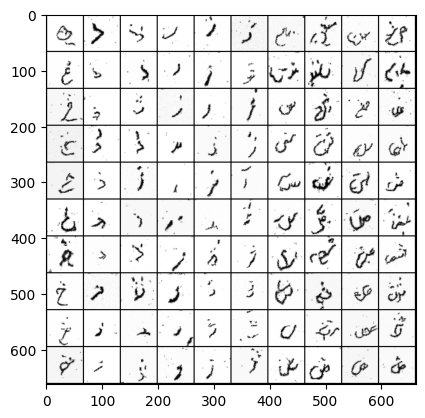

In [28]:
USE_TORCH_DIFFEQ = True
generated_class_list = torch.arange(10, device=device).repeat(10)
with torch.no_grad():
    if USE_TORCH_DIFFEQ:
        traj = torchdiffeq.odeint(
            lambda t, x: model.forward(t, x, generated_class_list),
            torch.randn(100, 1, 64, 64, device=device),
            torch.linspace(0, 1, 2, device=device),
            atol=1e-4,
            rtol=1e-4,
            method="dopri5",
        )
    else:
        traj = node.trajectory(
            torch.randn(100, 1, 64, 64, device=device),
            t_span=torch.linspace(0, 1, 2, device=device),
        )
grid = make_grid(
    traj[-1, :100].view([-1, 1, 64, 64]).clip(-1, 1), value_range=(-1, 1), padding=2, nrow=10
)
img = ToPILImage()(grid)
plt.imshow(img)
plt.show()

In [29]:
#################################
#            OT-CFM
#################################

sigma = 0.0
model = UNetModel(
    dim=(1, 64, 64), num_channels=32, num_res_blocks=1, num_classes=10, class_cond=True
).to(device)
optimizer = torch.optim.Adam(model.parameters())
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma)
node = NeuralODE(model, solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4)

In [30]:
for epoch in range(n_epochs):
    for i, data in enumerate(train_loader):
        optimizer.zero_grad()
        x1 = data[0].to(device)
        y = data[1].to(device)
        x0 = torch.randn_like(x1)
        t, xt, ut, _, y1 = FM.guided_sample_location_and_conditional_flow(x0, x1, y1=y)
        vt = model(t, xt, y1)
        loss = torch.mean((vt - ut) ** 2)
        loss.backward()
        optimizer.step()
        print(f"epoch: {epoch}, steps: {i}, loss: {loss.item():.4}", end="\r")

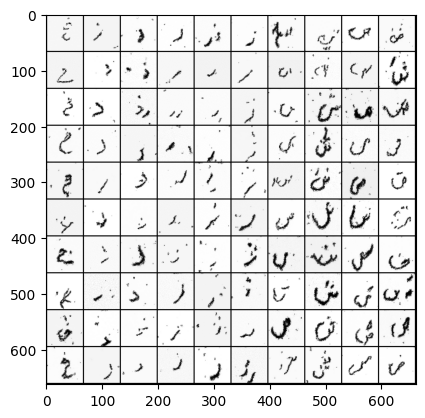

In [33]:
USE_TORCH_DIFFEQ = True
generated_class_list = torch.arange(10, device=device).repeat(10)
with torch.no_grad():
    if USE_TORCH_DIFFEQ:
        traj = torchdiffeq.odeint(
            lambda t, x: model.forward(t, x, generated_class_list),
            torch.randn(100, 1, 64, 64, device=device),
            torch.linspace(0, 1, 2, device=device),
            atol=1e-4,
            rtol=1e-4,
            method="dopri5",
        )
    else:
        traj = node.trajectory(
            torch.randn(100, 1, 64, 64, device=device),
            t_span=torch.linspace(0, 1, 2, device=device),
        )
grid = make_grid(
    traj[-1, :100].view([-1, 1, 64, 64]).clip(-1, 1), value_range=(-1, 1), padding=2, nrow=10
)
img = ToPILImage()(grid)
plt.imshow(img)
plt.show()

#### Complicated Unet

In [34]:
#################################
#            OT-CFM
#################################

sigma = 0.0
model = UNetModel(
    dim=(1, 64, 64), num_channels=32, num_res_blocks=2, num_classes=10, class_cond=True
).to(device)
optimizer = torch.optim.Adam(model.parameters())
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma)
node = NeuralODE(model, solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4)

In [35]:
for epoch in range(n_epochs):
    for i, data in tqdm(enumerate(train_loader),desc=f"epoch: {epoch}"):
        optimizer.zero_grad()
        x1 = data[0].to(device)
        y = data[1].to(device)
        x0 = torch.randn_like(x1)
        t, xt, ut, _, y1 = FM.guided_sample_location_and_conditional_flow(x0, x1, y1=y)
        vt = model(t, xt, y1)
        loss = torch.mean((vt - ut) ** 2)
        loss.backward()
        optimizer.step()
        # print(f"epoch: {epoch}, steps: {i}, loss: {loss.item():.4}", end="\r")

epoch: 0: 364it [00:38,  9.38it/s]
epoch: 1: 364it [00:37,  9.75it/s]
epoch: 2: 364it [00:38,  9.57it/s]
epoch: 3: 364it [00:38,  9.40it/s]
epoch: 4: 364it [00:38,  9.40it/s]
epoch: 5: 364it [00:36,  9.90it/s]
epoch: 6: 364it [00:38,  9.44it/s]
epoch: 7: 364it [00:32, 11.14it/s]
epoch: 8: 364it [00:25, 14.13it/s]
epoch: 9: 364it [00:25, 14.32it/s]
epoch: 10: 364it [00:25, 14.45it/s]
epoch: 11: 364it [00:25, 14.46it/s]
epoch: 12: 364it [00:25, 14.28it/s]
epoch: 13: 364it [00:25, 14.36it/s]
epoch: 14: 364it [00:25, 14.41it/s]
epoch: 15: 364it [00:25, 14.38it/s]
epoch: 16: 364it [00:25, 14.32it/s]
epoch: 17: 364it [00:25, 14.28it/s]
epoch: 18: 364it [00:25, 14.24it/s]
epoch: 19: 364it [00:25, 14.18it/s]


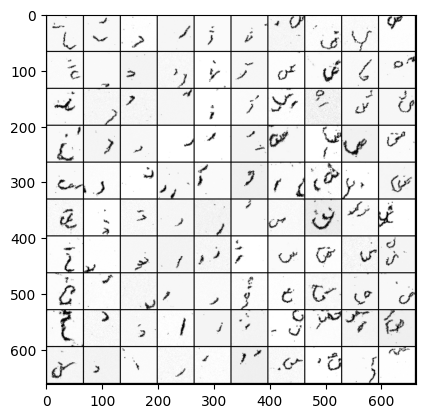

In [36]:
USE_TORCH_DIFFEQ = True
generated_class_list = torch.arange(10, device=device).repeat(10)
with torch.no_grad():
    if USE_TORCH_DIFFEQ:
        traj = torchdiffeq.odeint(
            lambda t, x: model.forward(t, x, generated_class_list),
            torch.randn(100, 1, 64, 64, device=device),
            torch.linspace(0, 1, 2, device=device),
            atol=1e-4,
            rtol=1e-4,
            method="dopri5",
        )
    else:
        traj = node.trajectory(
            torch.randn(100, 1, 64, 64, device=device),
            t_span=torch.linspace(0, 1, 2, device=device),
        )
grid = make_grid(
    traj[-1, :100].view([-1, 1, 64, 64]).clip(-1, 1), value_range=(-1, 1), padding=2, nrow=10
)
img = ToPILImage()(grid)
plt.imshow(img)
plt.show()